In [5]:
#cargar el dataset
import pandas as pd

df=pd.read_csv("data\Video_Games_Sales.csv")

df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#verificacion de columnas y tipos de datos
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
count,16717,16719,16450.000000,16717,16665,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,10015,7590.000000,10096,9950
unique,11562,31,NaN,12,581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,NaN,1696,8
top,Need for Speed: Most Wanted,PS2,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tbd,NaN,Ubisoft,E
freq,12,2161,NaN,3370,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2425,NaN,204,3991
mean,NaN,NaN,2006.487356,NaN,NaN,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,NaN,162.229908,NaN,NaN
std,NaN,NaN,5.878995,NaN,NaN,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,NaN,561.282326,NaN,NaN
min,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,NaN,4.000000,NaN,NaN
25%,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,NaN,10.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,NaN,24.000000,NaN,NaN
75%,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,NaN,81.000000,NaN,NaN


In [10]:
#limpiar y estandarizar nombres de columnas

df.columns=(df.columns
            .str.strip()
            .str.lower()
            .str.replace(' ','_')
            .str.replace('-','_')
            .str.replace('/','_')
            )

In [12]:
#verificar cantidad de valores nulos
df.isnull().sum()

name                  2
platform              0
year_of_release     269
genre                 2
publisher            54
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
global_sales          0
critic_score       8582
critic_count       8582
user_score         6704
user_count         9129
developer          6623
rating             6769
dtype: int64

In [13]:
# Ver porcentaje de valores nulos
(df.isnull().sum() / len(df)).sort_values(ascending=False)


user_count         0.546025
critic_score       0.513308
critic_count       0.513308
rating             0.404869
user_score         0.400981
developer          0.396136
year_of_release    0.016089
publisher          0.003230
name               0.000120
genre              0.000120
platform           0.000000
na_sales           0.000000
eu_sales           0.000000
jp_sales           0.000000
other_sales        0.000000
global_sales       0.000000
dtype: float64

In [16]:
#eliminar filas con pocos valores nulos
df = df.dropna(subset=['name','year_of_release', 'genre'])

In [32]:
# Columnas con muchos nulos rellenar con la media o mediana
df['critic_score'].fillna(df['critic_score'].mean(), inplace=True)
df['critic_count'].fillna(df['critic_count'].mean(), inplace=True)
df['user_count'].fillna(df['user_count'].mean(), inplace=True)


In [33]:
# marcar como "desconocido", algunos datos nulos
df['rating'].fillna('Desconocido', inplace=True)
df['publisher'].fillna('Desconocido', inplace=True)
df['developer'].fillna('Desconocido', inplace=True)


In [34]:
df.isnull().sum()


name                  0
platform              0
year_of_release       0
genre                 0
publisher             0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
global_sales          0
critic_score          0
critic_count          0
user_score         6608
user_count            0
developer             0
rating                0
dtype: int64

In [38]:
import numpy as np

# Ver valores únicos para entender qué contiene
print(df['user_score'].unique())
# Reemplazar 'tbd' por NaN (faltantes)
df['user_score'] = df['user_score'].replace('tbd', np.nan)

# Convertir a tipo float
df['user_score'] = df['user_score'].astype(float)
df['user_score'].fillna(df['user_score'].mean(), inplace=True)

[8.         7.12632989 8.3        8.5        6.6        8.4
 8.6        7.7        6.3        7.4        8.2        9.
 7.9        8.1        8.7        7.1        3.4        5.3
 4.8        3.2        8.9        6.4        7.8        7.5
 2.6        7.2        9.2        7.         7.3        4.3
 7.6        5.7        5.         9.1        6.5        8.8
 6.9        9.4        6.8        6.1        6.7        5.4
 4.         4.9        4.5        9.3        6.2        4.2
 6.         3.7        4.1        5.8        5.6        5.5
 4.4        4.6        5.9        3.9        3.1        2.9
 5.2        3.3        4.7        5.1        3.5        2.5
 1.9        3.         2.7        2.2        2.         9.5
 2.1        3.6        2.8        1.8        3.8        0.
 1.6        9.6        2.4        1.7        1.1        0.3
 1.5        0.7        1.2        2.3        0.5        1.3
 0.2        0.6        1.4        0.9        1.         9.7       ]


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo gráfico
sns.set(style="whitegrid", palette="muted")




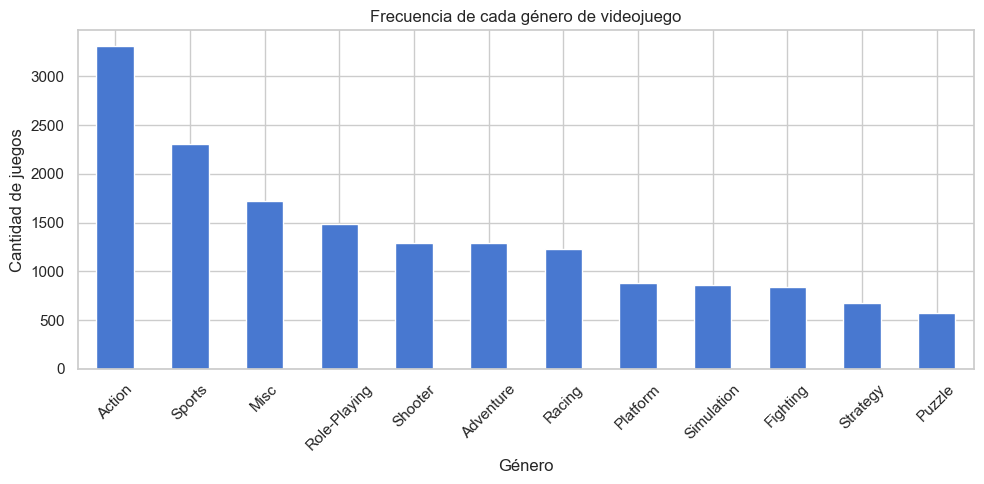

<Figure size 640x480 with 0 Axes>

In [46]:
# Análisis 1: ¿Cuáles son los géneros más comunes?
plt.figure(figsize=(10,5))
df['genre'].value_counts().plot(kind='bar')
plt.title("Frecuencia de cada género de videojuego")
plt.xlabel("Género")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('images/Géneros más comunes.png')

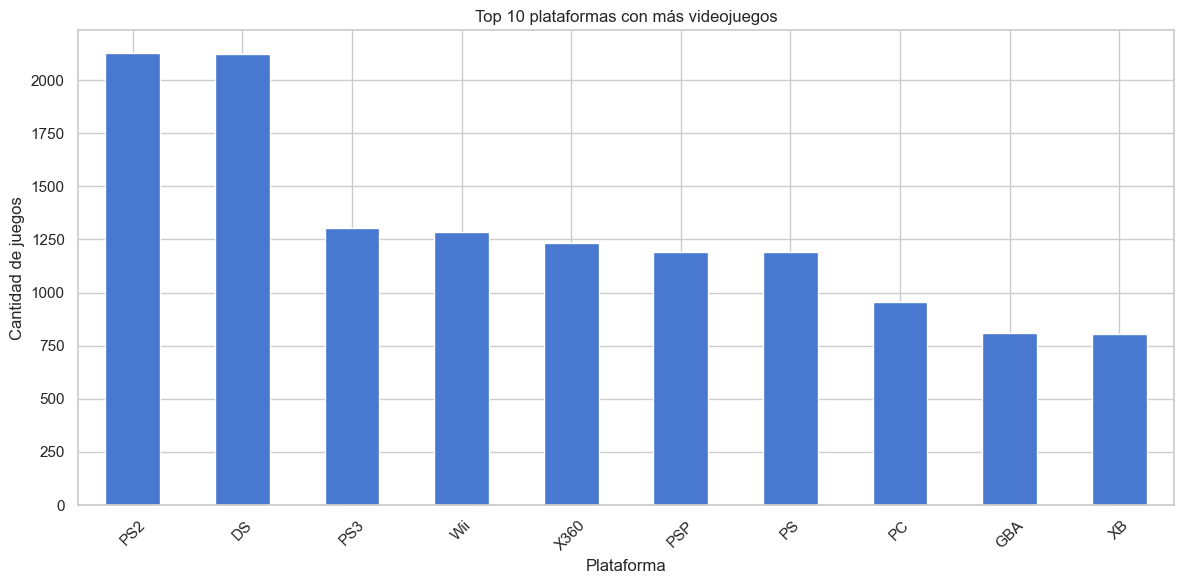

<Figure size 640x480 with 0 Axes>

In [47]:
# Análisis 2: ¿Qué plataformas tienen más juegos?
plt.figure(figsize=(12,6))
df['platform'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 plataformas con más videojuegos")
plt.xlabel("Plataforma")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('images/plataformas con mas juegos.png')

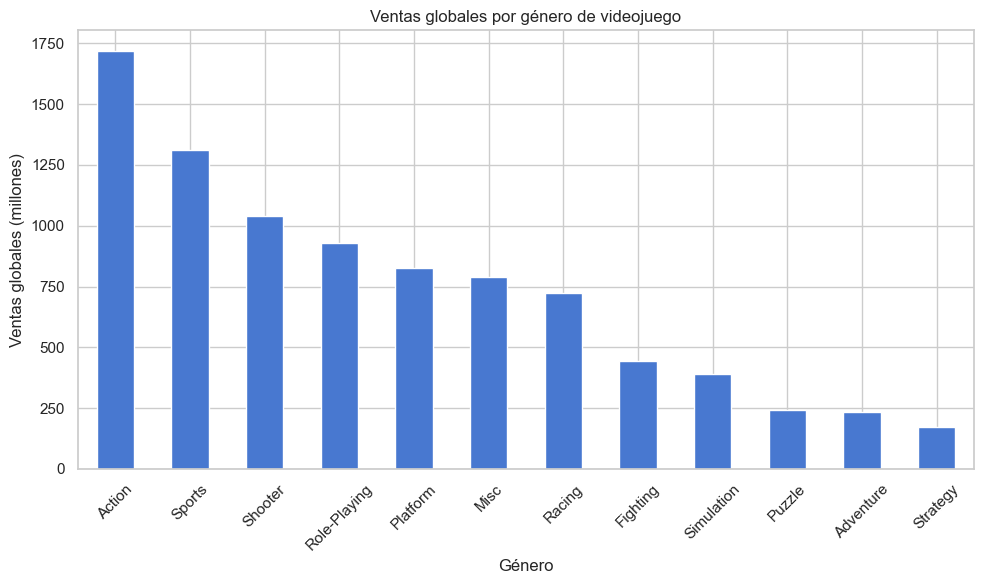

<Figure size 640x480 with 0 Axes>

In [49]:
#Análisis 3: Ventas globales por género
ventas_genero = df.groupby('genre')['global_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ventas_genero.plot(kind='bar')
plt.title("Ventas globales por género de videojuego")
plt.xlabel("Género")
plt.ylabel("Ventas globales (millones)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('images/ventas globales por genero.png')


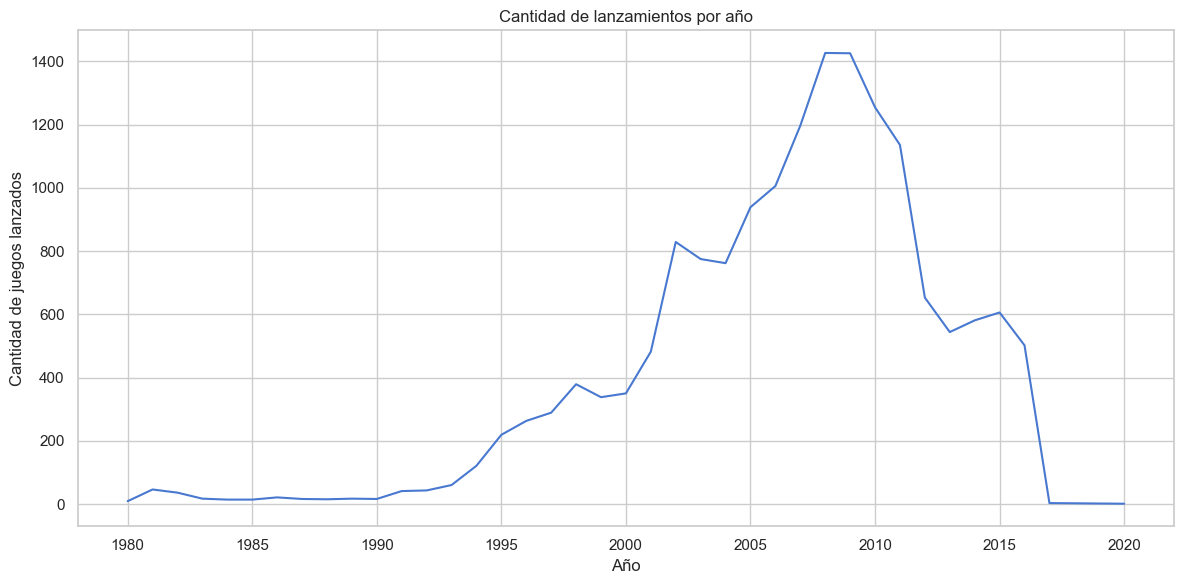

<Figure size 640x480 with 0 Axes>

In [51]:
#Análisis 4: Evolución de lanzamientos por año
plt.figure(figsize=(12,6))
df['year_of_release'].value_counts().sort_index().plot(kind='line')
plt.title("Cantidad de lanzamientos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de juegos lanzados")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('images/lanzamientos por año.png')